Missing values before cleaning:
Num                        0
Timestamp                  0
Current_J0                 0
Temperature_T0             0
Current_J1                 0
Temperature_J1             0
Current_J2                 0
Temperature_J2             0
Current_J3                 0
Temperature_J3             0
Current_J4                 0
Temperature_J4             0
Current_J5                 0
Temperature_J5             0
Speed_J0                   0
Speed_J1                   0
Speed_J2                   0
Speed_J3                   0
Speed_J4                   0
Speed_J5                   0
Tool_current               0
cycle                      0
Robot_ProtectiveStop       0
grip_lost                  0
Unnamed: 24             7355
Unnamed: 25             7355
Unnamed: 26             7355
Unnamed: 27             7355
Unnamed: 28             7355
Unnamed: 29             7355
Unnamed: 30             7355
Unnamed: 31             7355
Unnamed: 32             7355
Unnamed: 33

/var/folders/q5/t_k11b4n7bv1_yrk5qx88jjm0000gn/T/ipykernel_60243/3345642634.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


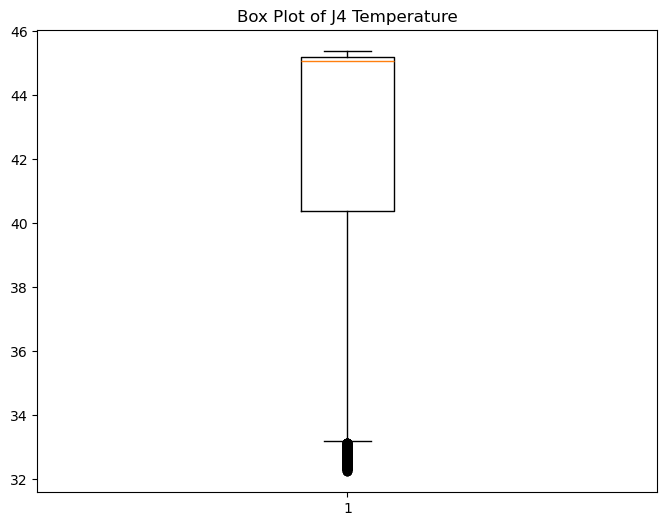


Missing values after cleaning:
Num                        0
Timestamp                  0
Current_J0                 0
Temperature_T0             0
Current_J1                 0
Temperature_J1             0
Current_J2                 0
Temperature_J2             0
Current_J3                 0
Temperature_J3             0
Current_J4                 0
Temperature_J4             0
Current_J5                 0
Temperature_J5             0
Speed_J0                   0
Speed_J1                   0
Speed_J2                   0
Speed_J3                   0
Speed_J4                   0
Speed_J5                   0
Tool_current               0
cycle                      0
Robot_ProtectiveStop       0
grip_lost                  0
Unnamed: 24             7216
Unnamed: 25             7216
Unnamed: 26             7216
Unnamed: 27             7216
Unnamed: 28             7216
Unnamed: 29             7216
Unnamed: 30             7216
Unnamed: 31             7216
Unnamed: 32             7216
Unnamed: 33

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Load the Dataset
# Assuming the UR3_CobotOps dataset is in a CSV file (e.g., 'ur3_cobotops.csv')
# You can find the dataset at the {Link: UCI Machine Learning Repository https://archive.ics.uci.edu/dataset/963/ur3+cobotops}.
data = pd.read_csv('UR3_CobotOps-cleaned.csv')
# 2. Check for Missing Values
print("Missing values before cleaning:")
print(data.isnull().sum())

# 3. Handle Missing Values (Example: using forward fill for time-series data)
# You can choose other imputation methods based on the specific nature of the missingness.
data.fillna(method='ffill', inplace=True) 

# 4. Remove Duplicates
data.drop_duplicates(inplace=True)

# 5. Outlier Detection and Treatment (Example using IQR method)
# This part is more complex as it involves feature-specific analysis.
# For demonstration purposes, let's illustrate for one feature: 'Temperature_J4'

# Plot a box plot to visually inspect for outliers
plt.figure(figsize=(8, 6))
plt.boxplot(data['Temperature_J4']) # 
plt.title('Box Plot of J4 Temperature')
plt.show()

# Calculate IQR to identify outliers
Q1 = data['Temperature_J4'].quantile(0.25)
Q3 = data['Temperature_J4'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers (can be done by filtering the DataFrame)
data = data[(data['Temperature_J4'] >= lower_bound) & (data['Temperature_J4'] <= upper_bound)]

# 6. Feature Scaling (Using StandardScaler for predictive maintenance example)
# The selected features will be scaled before training the model.
features_to_scale = ['Current_J0', 'Temperature_J0', 'Current_J1', 'Temperature_J1', 'Current_J2', 
                      'Temperature_J2', 'Current_J3', 'Temperature_J3', 'Current_J4', 
                      'Temperature_J4', 'Current_J5', 'Temperature_J5', 'Speed_J0', 
                      'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5', 
                      'Tool_current']

scaler = StandardScaler()
data[features_to_scale] = scaler.fit_transform(data[features_to_scale])

print("\nMissing values after cleaning:")
print(data.isnull().sum())
print("\nFirst 5 rows after cleaning and scaling:")
print(data.head())

Root Mean Squared Error (RMSE): 0.0004577570143430341
R-squared (R2): 0.9995593072587127


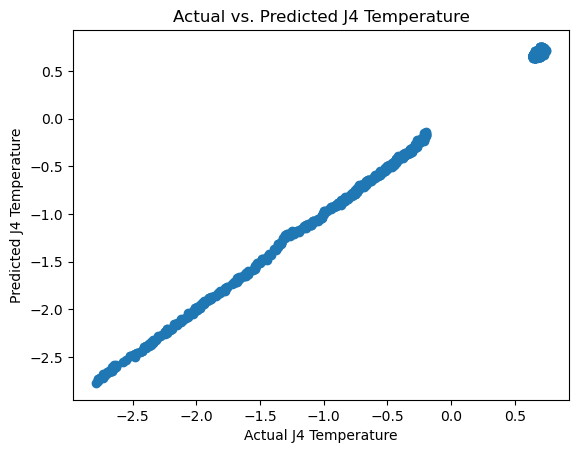


Coefficients:
           Feature  Coefficient
0   Temperature_T0     0.179945
1   Temperature_J1    -0.634301
2   Temperature_J2     0.285514
3   Temperature_J3     0.881177
4   Temperature_J5     0.286999
5         Speed_J0    -0.000248
6         Speed_J1    -0.000081
7         Speed_J2     0.000554
8         Speed_J3     0.000532
9         Speed_J4    -0.000654
10        Speed_J5     0.000137


In [40]:

# 2. Select Features (X) and Target (y)
# Let's use other joint temperatures and speeds to predict Joint 4 Temperature
features = ['Temperature_J0', 'Temperature_J1', 'Temperature_J2', 'Temperature_J3', 'Temperature_J5',
            'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
target = 'Temperature_J4'  # Predict Joint 4 Temperature

X = data[features]
y = data[target]

# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test)

# 6. Evaluate the Model
rmse = mean_squared_error(y_test, y_pred)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

# 7. Visualize the Results (Optional)
plt.scatter(y_test, y_pred) # 
plt.xlabel("Actual J4 Temperature")
plt.ylabel("Predicted J4 Temperature")
plt.title("Actual vs. Predicted J4 Temperature")
plt.show()

# 8. Analyze the Coefficients (Optional)
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print("\nCoefficients:")
print(coefficients)

Index(['Num', 'Timestamp', 'Current_J0', 'Temperature_T0', 'Current_J1',
       'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3',
       'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5',
       'Temperature_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3',
       'Speed_J4', 'Speed_J5', 'Tool_current', 'cycle', 'Robot_ProtectiveStop',
       'grip_lost', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31',
       'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35',
       'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39',
       'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42'],
      dtype='object')

/var/folders/q5/t_k11b4n7bv1_yrk5qx88jjm0000gn/T/ipykernel_60243/400970893.py:14: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data.interpolate(method='linear', inplace=True)


--- Joint Temperature Prediction for All Joints ---
Joint Temperature_T0 Prediction:
  Mean Squared Error (MSE): 0.02
  R-squared (R2): 1.00
Joint Temperature_J1 Prediction:
  Mean Squared Error (MSE): 0.01
  R-squared (R2): 1.00
Joint Temperature_J2 Prediction:
  Mean Squared Error (MSE): 0.01
  R-squared (R2): 1.00
Joint Temperature_J3 Prediction:
  Mean Squared Error (MSE): 0.02
  R-squared (R2): 1.00
Joint Temperature_J4 Prediction:
  Mean Squared Error (MSE): 0.02
  R-squared (R2): 1.00


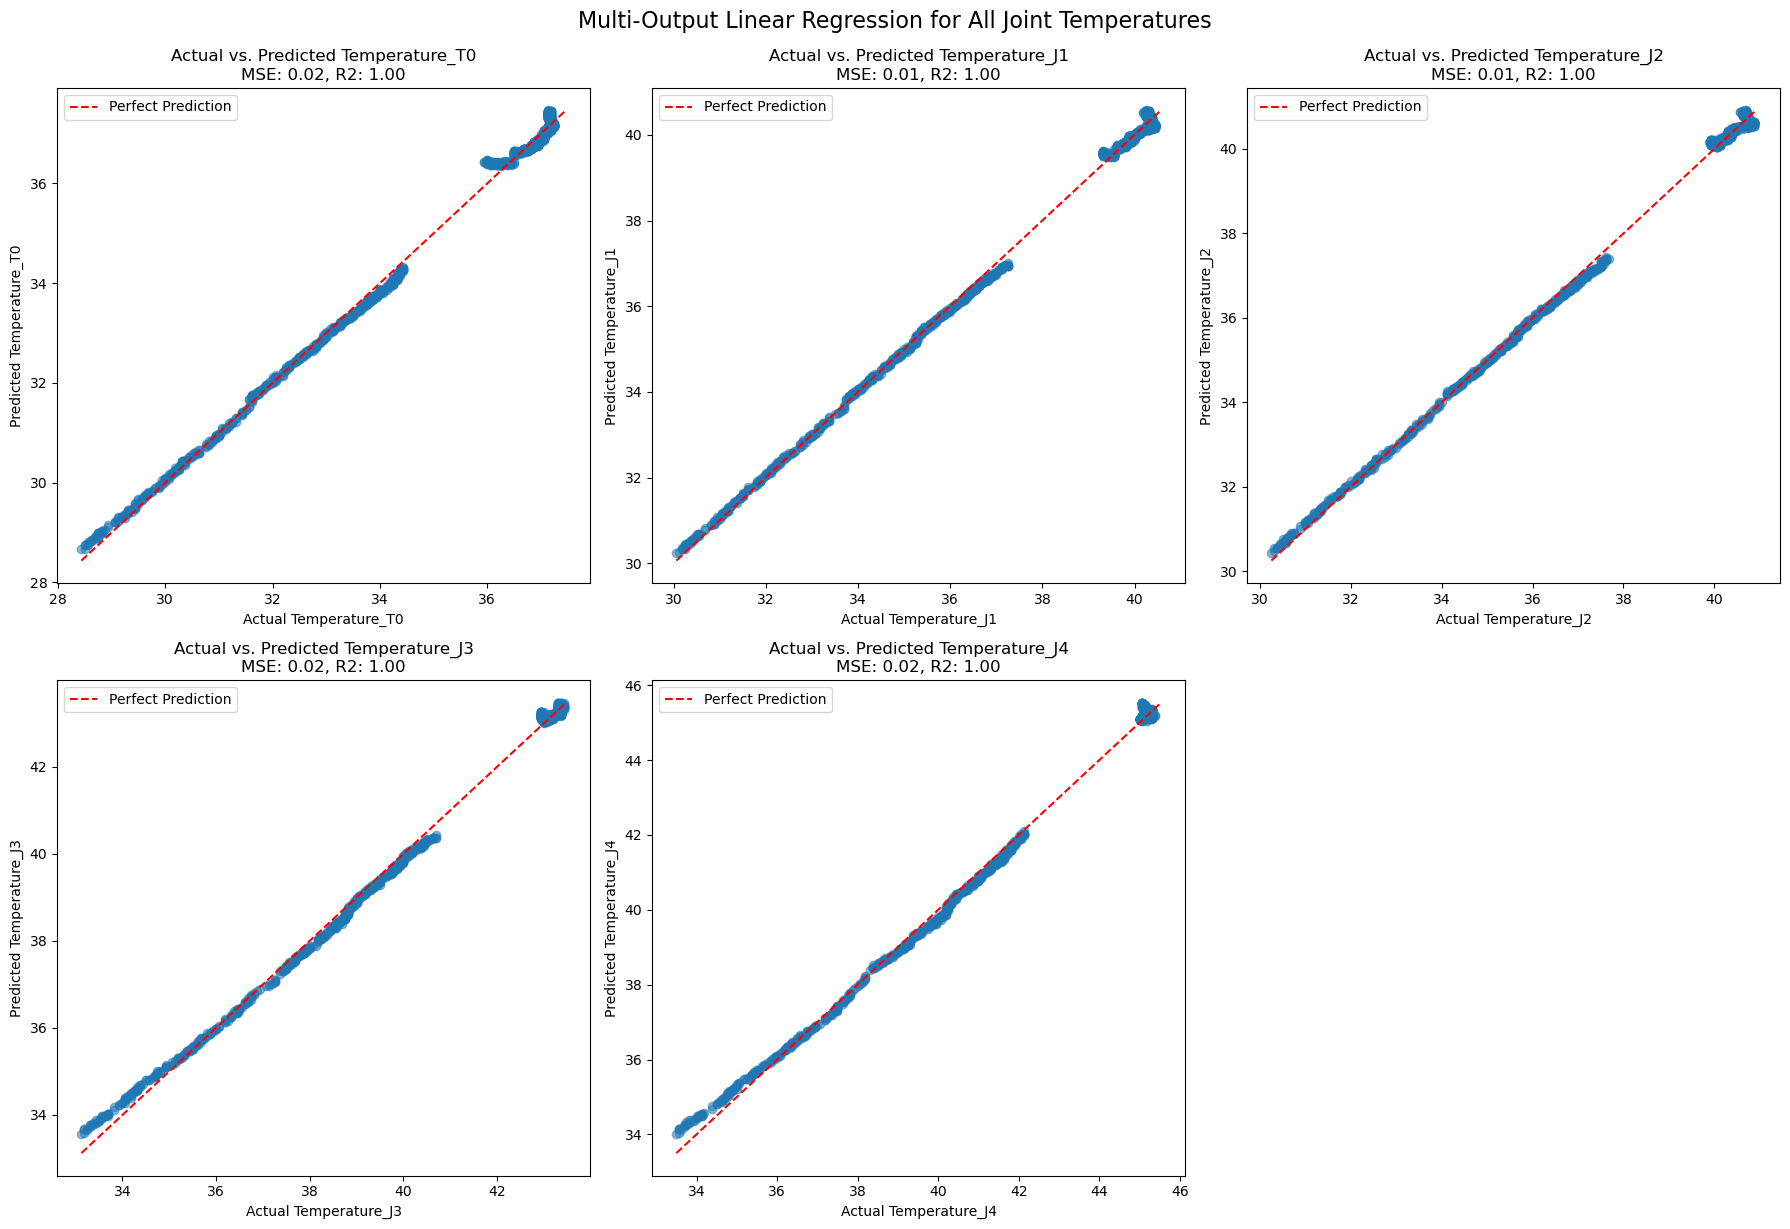


--- Coefficients for All Joint Temperature Predictions (Scaled Features) ---

Coefficients for Temperature_T0:
                  Feature  Coefficient (Temperature_T0)
16         Temperature_J5                      2.005603
18                 cycle                       0.611246
17               Speed_J5                      0.028776
7                Speed_J3                      0.018419
1                Speed_J0                      0.009116
10  Current_J0_x_Speed_J0                      0.004206
2              Current_J1                      0.004025
0              Current_J0                      0.003997
8              Current_J4                      0.003262
6              Current_J3                      0.001976
11  Current_J1_x_Speed_J1                      0.001896
9                Speed_J4                     -0.002646
14  Current_J4_x_Speed_J4                     -0.003020
5                Speed_J2                     -0.003491
12  Current_J2_x_Speed_J2                     -0

In [96]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Dataset
data = pd.read_excel('UR3_CobotOps.xlsx')

data = data.infer_objects(copy=False)
# 2. Data Cleaning: Handle missing values with linear interpolation and remove duplicates.
data.interpolate(method='linear', inplace=True)
data.drop_duplicates(inplace=True)

# Define the target variables (all joint temperatures)
temperature_targets = ['Temperature_J0', 'Temperature_J1', 'Temperature_J2',
                       'Temperature_J3', 'Temperature_J4']

# Outlier treatment for all target variables (temperatures)
for target_col in temperature_targets:
    Q1 = data[target_col].quantile(0.25)
    Q3 = data[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[target_col] >= lower_bound) & (data[target_col] <= upper_bound)]

# 3. Feature Engineering and Selection:
# Create absolute values for all joint currents and speeds
for i in range(6):
    data[f'Current_J{i}_abs'] = np.abs(data[f'Current_J{i}'])
    data[f'Speed_J{i}_abs'] = np.abs(data[f'Speed_J{i}'])

# Create interaction terms for current and speed for each joint
for i in range(6):
    data[f'Current_J{i}_x_Speed_J{i}'] = data[f'Current_J{i}_abs'] * data[f'Speed_J{i}_abs']

# Define all potential features (excluding original Current and Speed columns)
all_potential_features = ['Current_J0', 'Speed_J0',  # Direct Joint 0 info
            'Current_J1', 'Speed_J1',  # Direct Joint 1 info
            'Current_J2', 'Speed_J2',  # Direct Joint 2 info
            'Current_J3', 'Speed_J3',  # Direct Joint 3 info
            'Current_J4', 'Speed_J4',  # Direct Joint 4 info
            'Current_J0_x_Speed_J0',  # J0 interaction term
            'Current_J1_x_Speed_J1',  # J1 interaction term
            'Current_J2_x_Speed_J2',  # J2 interaction term
            'Current_J3_x_Speed_J3',  # J3 interaction term
            'Current_J4_x_Speed_J4',  # J4 interaction term
            'Temperature_J0', # Include J0 Temp as feature for other joints
            'Temperature_J1', # Include J1 Temp as feature for other joints
            'Temperature_J2', # Include J2 Temp as feature for other joints
            'Temperature_J3', # Include J3 Temp as feature for other joints
            'Temperature_J4', # Include J4 Temp as feature for other joints
            'Current_J5', 'Temperature_J5', 'Speed_J5', # Joint 5 (neighbor of J4)
            'cycle '                                   # System context
           ]

# Features will be all potential features *except* the target temperatures themselves
features = [f for f in all_potential_features if f not in temperature_targets]

X = data[features]
y = data[temperature_targets]

# 4. Feature Scaling (Using StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. Create and Train the Multi-Output Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = model.predict(X_test)

# 8. Evaluate the Model and Visualize the Results
print("--- Joint Temperature Prediction for All Joints ---")
plt.figure(figsize=(18, 12)) # Adjust figure size for all subplots

for i, col in enumerate(temperature_targets):
    # Calculate Mean Squared Error (MSE)
    mse = mean_squared_error(y_test[col], y_pred[:, i])
    r2 = r2_score(y_test[col], y_pred[:, i])

    print(f"Joint {col} Prediction:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

    # Plot for each joint's temperature
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    plt.scatter(y_test[col], y_pred[:, i], alpha=0.5) # Add transparency for better visualization
    plt.xlabel(f"Actual {col}")
    plt.ylabel(f"Predicted {col}")
    plt.title(f"Actual vs. Predicted {col}\nMSE: {mse:.2f}, R2: {r2:.2f}")

    # Add the predicted line
    min_val = min(y_test[col].min(), y_pred[:, i].min())
    max_val = max(y_test[col].max(), y_pred[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
    plt.legend()

plt.tight_layout()
plt.suptitle("Multi-Output Linear Regression for All Joint Temperatures", y=1.02, fontsize=16) # Add a main title
plt.show()

# 9. Analyze the Coefficients (Optional)
print("\n--- Coefficients for All Joint Temperature Predictions (Scaled Features) ---")
for i, target_col in enumerate(temperature_targets):
    coefficients_df = pd.DataFrame({'Feature': features, f'Coefficient ({target_col})': model.coef_[i]})
    print(f"\nCoefficients for {target_col}:")
    print(coefficients_df.sort_values(by=f'Coefficient ({target_col})', ascending=False))


/var/folders/q5/t_k11b4n7bv1_yrk5qx88jjm0000gn/T/ipykernel_60243/3027757488.py:17: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data.interpolate(method='linear', inplace=True)


--- Joint 0, 1, 2, 3, and 4 Temperature Prediction (Multi-Output, Raw Values) ---
Joint Temperature_J0 Prediction:
  Mean Squared Error (MSE): 0.12
  R-squared (R2): 0.98
Joint Temperature_J1 Prediction:
  Mean Squared Error (MSE): 0.11
  R-squared (R2): 0.99
Joint Temperature_J2 Prediction:
  Mean Squared Error (MSE): 0.08
  R-squared (R2): 0.99
Joint Temperature_J3 Prediction:
  Mean Squared Error (MSE): 0.03
  R-squared (R2): 1.00
Joint Temperature_J4 Prediction:
  Mean Squared Error (MSE): 0.02
  R-squared (R2): 1.00


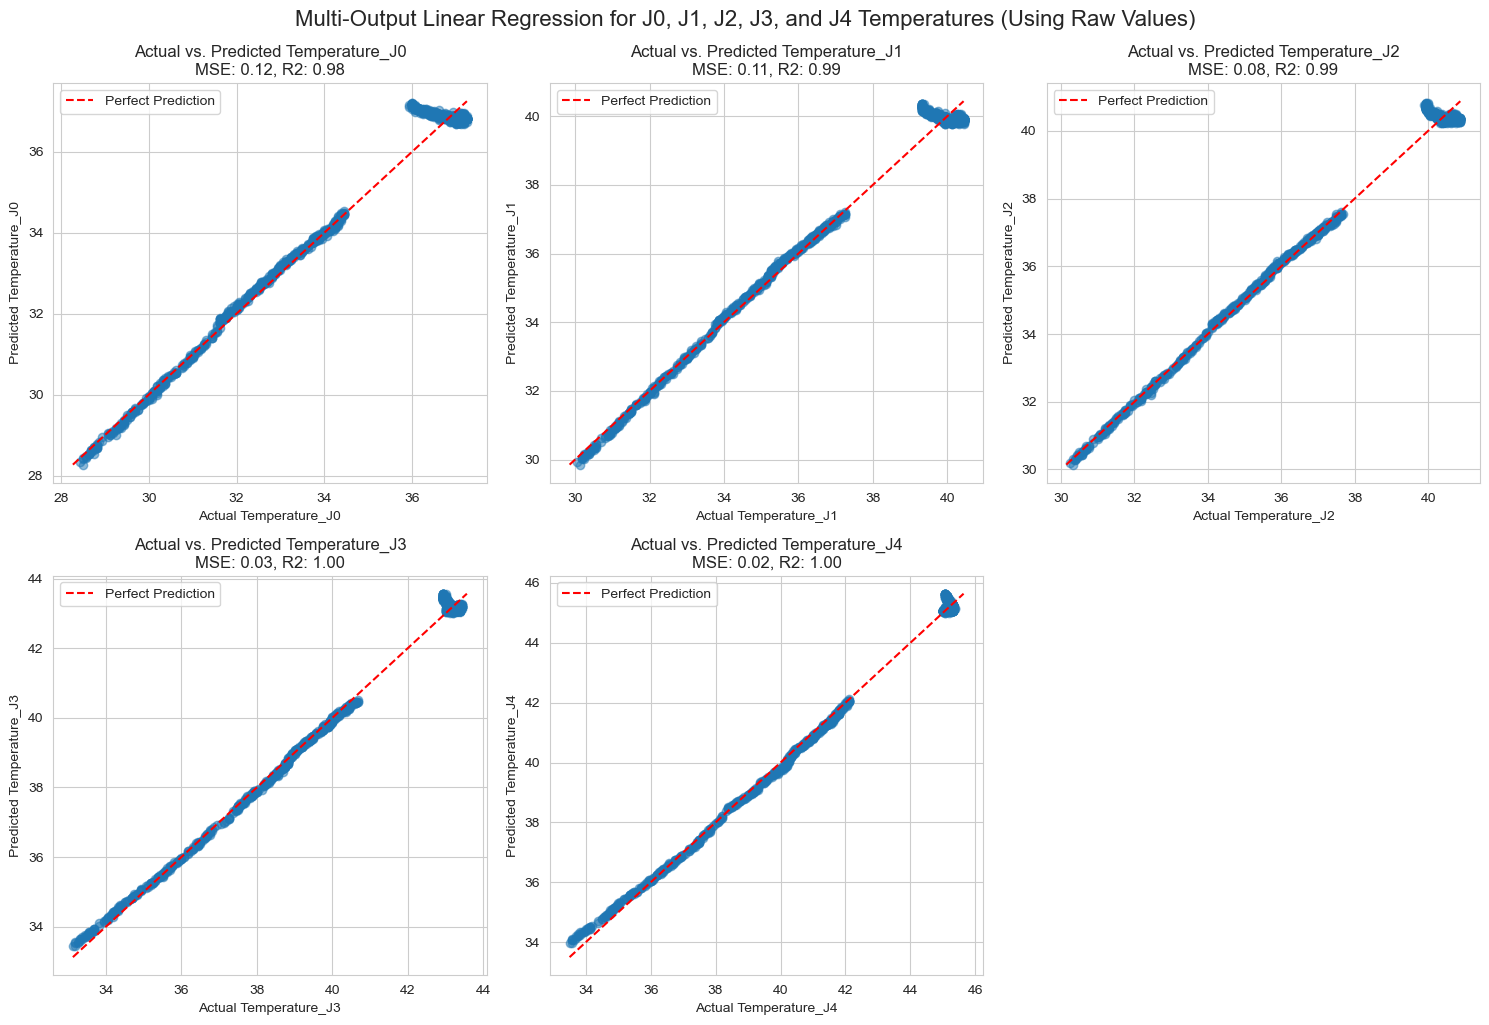


--- Coefficients for J0, J1, J2, J3, and J4 Temperature Prediction (Scaled Features, Raw Values) ---

Coefficients for Temperature_J0:
                  Feature  Coefficient (Temperature_J0)
16         Temperature_J5                      2.533967
7                Speed_J3                      0.153417
17               Speed_J5                      0.144343
1                Speed_J0                      0.072831
11  Current_J1_x_Speed_J1                      0.028113
3                Speed_J1                      0.018197
15             Current_J5                      0.015802
0              Current_J0                      0.007825
14  Current_J4_x_Speed_J4                      0.006982
8              Current_J4                      0.006403
12  Current_J2_x_Speed_J2                      0.005473
4              Current_J2                      0.001429
2              Current_J1                     -0.000201
10  Current_J0_x_Speed_J0                     -0.000801
5                Speed_J

In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Dataset
data = pd.read_excel('UR3_CobotOps.xlsx')

# 2. Data Cleaning:
# Infer better dtypes for object columns before interpolation
data = data.infer_objects(copy=False)

# Handle missing values with linear interpolation
data.interpolate(method='linear', inplace=True)

# Remove duplicates
data.drop_duplicates(inplace=True)

# Define the target variables (Joints 0, 1, 2, 3, and 4 Temperatures)
temperature_targets = ['Temperature_J0', 'Temperature_J1', 'Temperature_J2', 'Temperature_J3', 'Temperature_J4']

# Outlier treatment for the target variables
for target_col in temperature_targets:
    Q1 = data[target_col].quantile(0.25)
    Q3 = data[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[target_col] >= lower_bound) & (data[target_col] <= upper_bound)]

# 3. Feature Engineering and Selection:
# Create interaction terms for current and speed for Joints 0, 1, 2, 3, and 4 using raw values
for i in [0, 1, 2, 3, 4]:
    current_col = f'Current_J{i}'
    speed_col = f'Speed_J{i}'
    if current_col in data.columns and speed_col in data.columns:
        data[f'{current_col}_x_{speed_col}'] = data[current_col] * data[speed_col]
    else:
        print(f"Warning: {current_col} or {speed_col} not found in DataFrame. Skipping interaction term for J{i}.")

# Define the features (using raw values, no absolute values)
features = ['Current_J0', 'Speed_J0',  # Direct Joint 0 info
            'Current_J1', 'Speed_J1',  # Direct Joint 1 info
            'Current_J2', 'Speed_J2',  # Direct Joint 2 info
            'Current_J3', 'Speed_J3',  # Direct Joint 3 info
            'Current_J4', 'Speed_J4',  # Direct Joint 4 info
            'Current_J0_x_Speed_J0',  # J0 interaction term
            'Current_J1_x_Speed_J1',  # J1 interaction term
            'Current_J2_x_Speed_J2',  # J2 interaction term
            'Current_J3_x_Speed_J3',  # J3 interaction term
            'Current_J4_x_Speed_J4',  # J4 interaction term
            'Temperature_J0', # Include J0 Temp as feature for other joints
            'Temperature_J1', # Include J1 Temp as feature for other joints
            'Temperature_J2', # Include J2 Temp as feature for other joints
            'Temperature_J3', # Include J3 Temp as feature for other joints
            'Temperature_J4', # Include J4 Temp as feature for other joints
            'Current_J5', 'Temperature_J5', 'Speed_J5',  # Joint 5 (neighbor of J4)
            'cycle '                                   # System context
           ]

# Ensure only valid features are kept if some were skipped due to missing columns
features = [f for f in features if f in data.columns and f not in temperature_targets]

X = data[features]
y = data[temperature_targets]

# 4. Feature Scaling (Using StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. Create and Train the Multi-Output Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = model.predict(X_test)

# 8. Evaluate the Model: Calculate MSE and R-squared for all five outputs.
print("--- Joint 0, 1, 2, 3, and 4 Temperature Prediction (Multi-Output, Raw Values) ---")
plt.figure(figsize=(15, 10)) # Adjust figure size for five subplots

for i, col in enumerate(temperature_targets):
    # Calculate Mean Squared Error (MSE)
    mse = mean_squared_error(y_test[col], y_pred[:, i])
    r2 = r2_score(y_test[col], y_pred[:, i])

    print(f"Joint {col} Prediction:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

    # Plot for each joint's temperature
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    plt.scatter(y_test[col], y_pred[:, i], alpha=0.5) # Add transparency for better visualization
    plt.xlabel(f"Actual {col}")
    plt.ylabel(f"Predicted {col}")
    plt.title(f"Actual vs. Predicted {col}\nMSE: {mse:.2f}, R2: {r2:.2f}")

    # Add the predicted line
    min_val = min(y_test[col].min(), y_pred[:, i].min())
    max_val = max(y_test[col].max(), y_pred[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
    plt.legend()

plt.tight_layout()
plt.suptitle("Multi-Output Linear Regression for J0, J1, J2, J3, and J4 Temperatures (Using Raw Values)", y=1.02, fontsize=16) # Add a main title
plt.show()

# 9. Analyze the Coefficients (Optional)
print("\n--- Coefficients for J0, J1, J2, J3, and J4 Temperature Prediction (Scaled Features, Raw Values) ---")
# The coefficients will be a 2D array: rows are target variables, columns are features
for i, target_col in enumerate(temperature_targets):
    coefficients_df = pd.DataFrame({'Feature': features, f'Coefficient ({target_col})': model.coef_[i]})
    print(f"\nCoefficients for {target_col}:")
    print(coefficients_df.sort_values(by=f'Coefficient ({target_col})', ascending=False))


/var/folders/q5/t_k11b4n7bv1_yrk5qx88jjm0000gn/T/ipykernel_60243/1544267024.py:15: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data.interpolate(method='linear', inplace=True)


--- Training Models to Predict ALL Joint Temperatures (Using Features from J1-J4) ---

--- Evaluation & Visualization (Actual vs Predicted for All Joints) ---

Joint Temperature_J0 Prediction:
  Linear - MSE: 0.01, R2: 1.00
  Ridge  - MSE: 0.01, R2: 1.00
  Lasso  - MSE: 0.01, R2: 1.00

Joint Temperature_J1 Prediction:
  Linear - MSE: 0.00, R2: 1.00
  Ridge  - MSE: 0.00, R2: 1.00
  Lasso  - MSE: 0.00, R2: 1.00

Joint Temperature_J2 Prediction:
  Linear - MSE: 0.00, R2: 1.00
  Ridge  - MSE: 0.00, R2: 1.00
  Lasso  - MSE: 0.00, R2: 1.00

Joint Temperature_J3 Prediction:
  Linear - MSE: 0.00, R2: 1.00
  Ridge  - MSE: 0.00, R2: 1.00
  Lasso  - MSE: 0.00, R2: 1.00

Joint Temperature_J4 Prediction:
  Linear - MSE: 0.00, R2: 1.00
  Ridge  - MSE: 0.00, R2: 1.00
  Lasso  - MSE: 0.00, R2: 1.00

Joint Temperature_J5 Prediction:
  Linear - MSE: 0.02, R2: 1.00
  Ridge  - MSE: 0.02, R2: 1.00
  Lasso  - MSE: 0.03, R2: 1.00


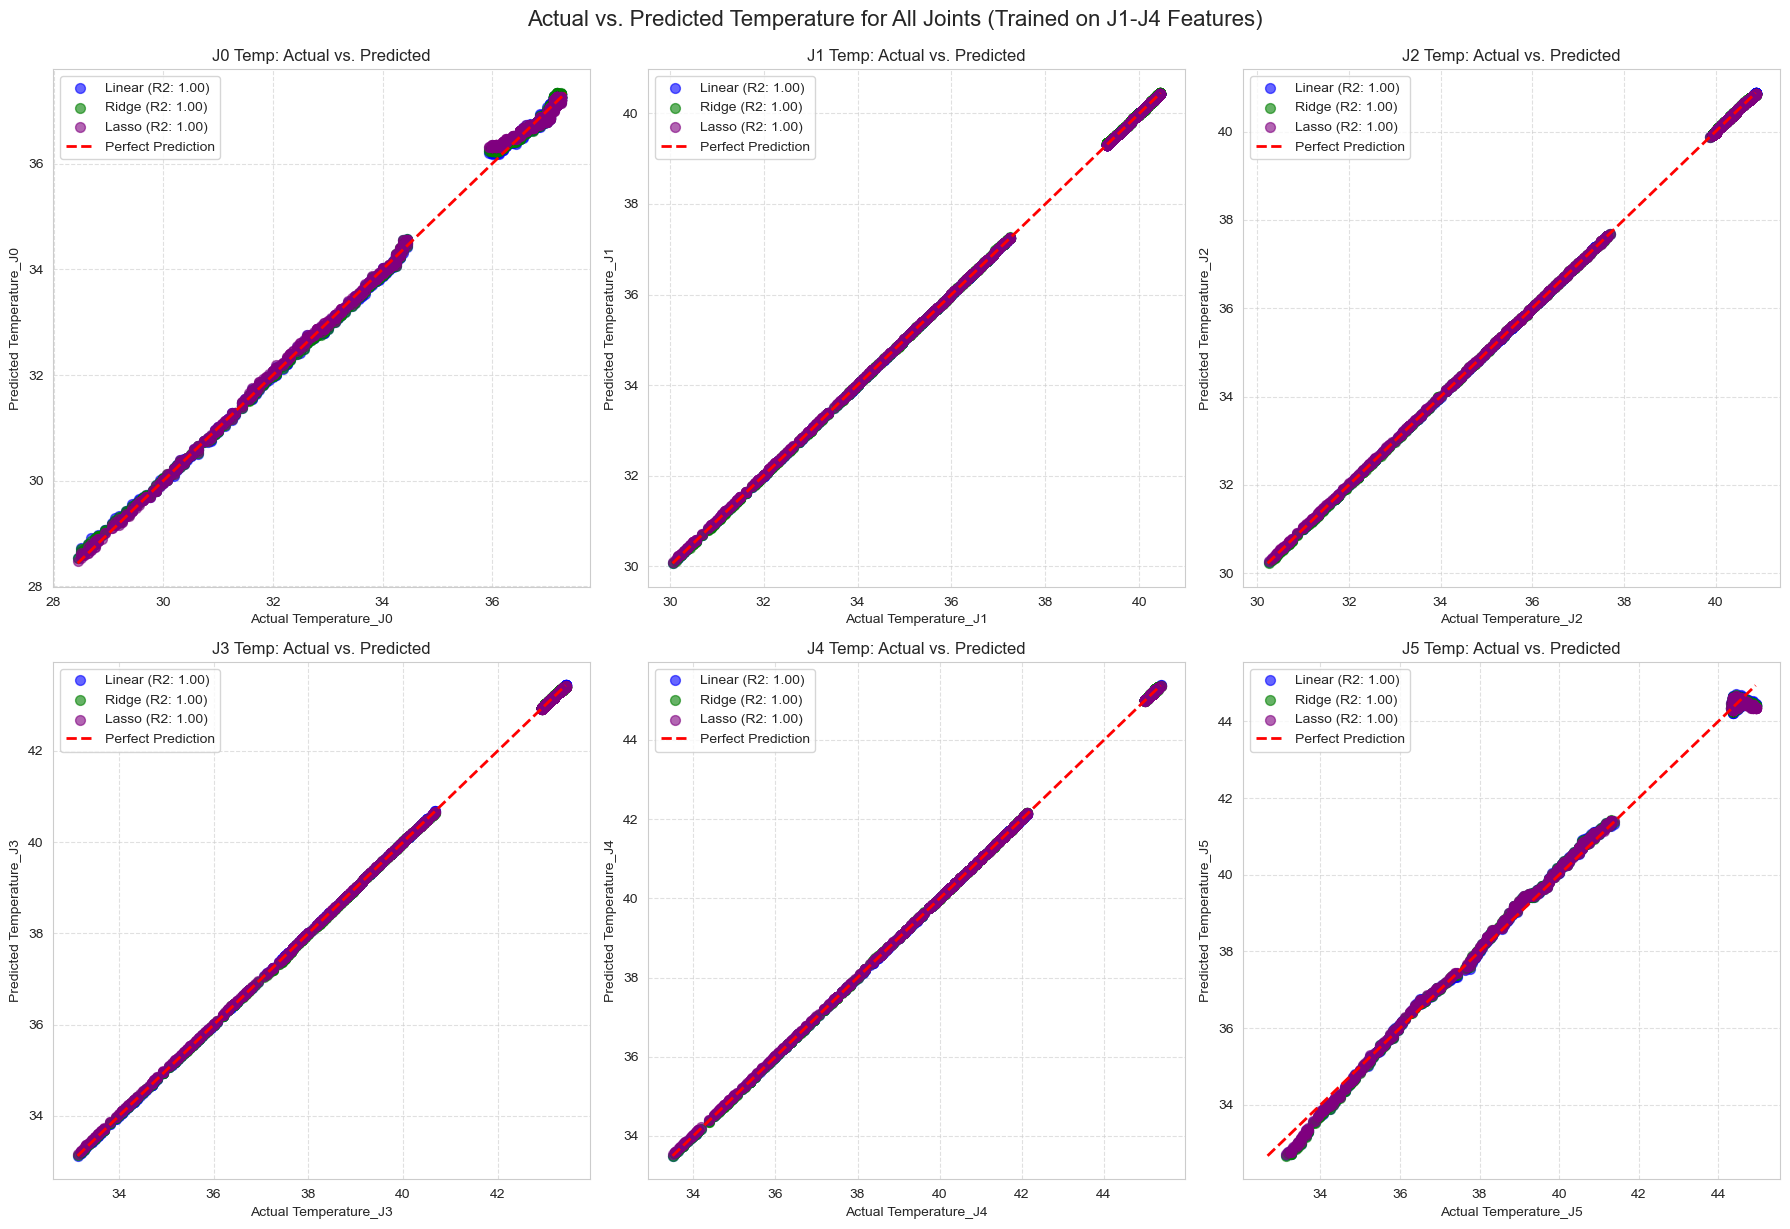


--- Coefficients for All Joint Temp Predictions (Trained on J1-J4) ---

Coefficients for Temperature_J0 (Linear):
                  Feature  Coefficient
0          Temperature_J1     3.807042
12         Temperature_J4     0.044745
7   Current_J2_x_Speed_J2     0.006551
6                Speed_J2     0.003198
11  Current_J3_x_Speed_J3     0.002604
           Feature  Coefficient
4   Temperature_J2    -0.931277
8   Temperature_J3    -0.365848
9       Current_J3    -0.003535
10        Speed_J3    -0.002004
5       Current_J2    -0.000627

Coefficients for Temperature_J0 (Ridge):
                 Feature  Coefficient
0         Temperature_J1     2.664832
4         Temperature_J2     0.408082
7  Current_J2_x_Speed_J2     0.006114
6               Speed_J2     0.003635
3  Current_J1_x_Speed_J1     0.002305
           Feature  Coefficient
12  Temperature_J4    -0.350921
8   Temperature_J3    -0.168779
5       Current_J2    -0.003018
10        Speed_J3    -0.003000
9       Current_J3    -0.0023

In [139]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Dataset
data = pd.read_excel('UR3_CobotOps.xlsx')

# 2. Data Cleaning:
data = data.infer_objects(copy=False)
data.interpolate(method='linear', inplace=True)
data.drop_duplicates(inplace=True)

# Define ALL target variables (all joint temperatures)
temperature_targets = ['Temperature_J0', 'Temperature_J1', 'Temperature_J2',
                       'Temperature_J3', 'Temperature_J4', 'Temperature_J5']

# Outlier treatment for ALL target variables (temperatures)
for target_col in temperature_targets:
    Q1 = data[target_col].quantile(0.25)
    Q3 = data[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[target_col] >= lower_bound) & (data[target_col] <= upper_bound)]

# 3. Feature Engineering and Selection:
# Create interaction terms for current and speed for all joints 0 to 5 (features might use them)
for i in range(6):
    current_col = f'Current_J{i}'
    speed_col = f'Speed_J{i}'
    if current_col in data.columns and speed_col in data.columns:
        data[f'{current_col}_x_{speed_col}'] = data[current_col] * data[speed_col]
    else:
        print(f"Warning: {current_col} or {speed_col} not found in DataFrame. Skipping interaction term for J{i}.")

# --- CRITICAL STEP: Define Features ONLY from Joints 1 to 4 ---
features = []
for i in range(1, 5): # Features from J1 to J4
    temp_col = f'Temperature_J{i}' # Note: J0 has Temperature_T0, others are Temperature_J*
    current_col = f'Current_J{i}'
    speed_col = f'Speed_J{i}'
    interaction_col = f'{current_col}_x_{speed_col}'

    features.extend([temp_col, current_col, speed_col])
    if interaction_col in data.columns:
        features.append(interaction_col)

features.append('cycle ') # Add system context, if considered general enough

# Ensure only valid features are kept
features = [f for f in features if f in data.columns]

X = data[features]
y = data[temperature_targets] # ALL joint temperatures as targets

# 4. Feature Scaling (Using StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. Train the Models
print("--- Training Models to Predict ALL Joint Temperatures (Using Features from J1-J4) ---")

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Ridge Regression
ridge_model = MultiOutputRegressor(Ridge(alpha=1.0, random_state=42)) # Use appropriate alpha
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Lasso Regression
lasso_model = MultiOutputRegressor(Lasso(alpha=0.01, random_state=42, max_iter=10000)) # Use appropriate alpha
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)


# 7. Evaluate and Visualize (Actual vs Predicted Plots for All Joints)
print("\n--- Evaluation & Visualization (Actual vs Predicted for All Joints) ---")
plt.figure(figsize=(18, 12)) # Adjust figure size for all subplots

for i, col in enumerate(temperature_targets):
    # Evaluate Linear Regression
    mse_linear = mean_squared_error(y_test[col], y_pred_linear[:, i])
    r2_linear = r2_score(y_test[col], y_pred_linear[:, i])

    # Evaluate Ridge
    mse_ridge = mean_squared_error(y_test[col], y_pred_ridge[:, i])
    r2_ridge = r2_score(y_test[col], y_pred_ridge[:, i])

    # Evaluate Lasso
    mse_lasso = mean_squared_error(y_test[col], y_pred_lasso[:, i])
    r2_lasso = r2_score(y_test[col], y_pred_lasso[:, i])

    print(f"\nJoint {col} Prediction:")
    print(f"  Linear - MSE: {mse_linear:.2f}, R2: {r2_linear:.2f}")
    print(f"  Ridge  - MSE: {mse_ridge:.2f}, R2: {r2_ridge:.2f}")
    print(f"  Lasso  - MSE: {mse_lasso:.2f}, R2: {r2_lasso:.2f}")

    # Plot for each joint's temperature (Actual vs Predicted)
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns

    # Actual vs Predicted scatter plots for each model
    plt.scatter(y_test[col], y_pred_linear[:, i], alpha=0.6, s=50, label=f'Linear (R2: {r2_linear:.2f})', color='blue')
    plt.scatter(y_test[col], y_pred_ridge[:, i], alpha=0.6, s=50, label=f'Ridge (R2: {r2_ridge:.2f})', color='green')
    plt.scatter(y_test[col], y_pred_lasso[:, i], alpha=0.6, s=50, label=f'Lasso (R2: {r2_lasso:.2f})', color='purple')

    # Add the line of perfect prediction (y=x line)
    min_val = min(y_test[col].min(), y_pred_linear[:, i].min(), y_pred_ridge[:, i].min(), y_pred_lasso[:, i].min())
    max_val = max(y_test[col].max(), y_pred_linear[:, i].max(), y_pred_ridge[:, i].max(), y_pred_lasso[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

    plt.xlabel(f"Actual {col}")
    plt.ylabel(f"Predicted {col}")
    plt.title(f"J{i if i > 0 else '0'} Temp: Actual vs. Predicted")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle("Actual vs. Predicted Temperature for All Joints (Trained on J1-J4 Features)", y=1.02, fontsize=16)
plt.show()

# 8. Analyze the Coefficients (Optional) - Can be very large.
# Consider printing only top/bottom coefficients or for specific joints if output is too long.
print("\n--- Coefficients for All Joint Temp Predictions (Trained on J1-J4) ---")
for i, target_col in enumerate(temperature_targets):
    print(f"\nCoefficients for {target_col} (Linear):")
    coefs_df_linear = pd.DataFrame({'Feature': features, 'Coefficient': linear_model.coef_[i]})
    print(coefs_df_linear.sort_values(by='Coefficient', ascending=False).head(5))
    print(coefs_df_linear.sort_values(by='Coefficient', ascending=True).head(5))

    print(f"\nCoefficients for {target_col} (Ridge):")
    coefs_df_ridge = pd.DataFrame({'Feature': features, 'Coefficient': ridge_model.estimators_[i].coef_})
    print(coefs_df_ridge.sort_values(by='Coefficient', ascending=False).head(5))
    print(coefs_df_ridge.sort_values(by='Coefficient', ascending=True).head(5))

    print(f"\nCoefficients for {target_col} (Lasso):")
    coefs_df_lasso = pd.DataFrame({'Feature': features, 'Coefficient': lasso_model.estimators_[i].coef_})
    print(coefs_df_lasso.sort_values(by='Coefficient', ascending=False).head(5))
    print(coefs_df_lasso.sort_values(by='Coefficient', ascending=True).head(5))


In [92]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Example: Discretize a few key features for demonstration
# (You would do this for all relevant features)
data_association = data[['Current_J0', 'Temperature_J0', 'Speed_J0', 'Robot_ProtectiveStop']].copy()
data_association['Current_J0_level'] = pd.cut(data_association['Current_J0'], bins=3, labels=['low_curr_J0', 'med_curr_J0', 'high_curr_J0'])
data_association['Temperature_J0_level'] = pd.cut(data_association['Temperature_J0'], bins=3, labels=['low_temp_T0', 'med_temp_T0', 'high_temp_T0'])
data_association['Speed_J0_level'] = pd.cut(data_association['Speed_J0'], bins=3, labels=['low_speed_J0', 'med_speed_J0', 'high_speed_J0'])
data_association['ProtectiveStop_Event'] = data_association['Robot_ProtectiveStop'].astype(bool)

# Select only the discretized/boolean columns for association rule mining
items = data_association[['Current_J0_level', 'Temperature_J0_level', 'Speed_J0_level', 'ProtectiveStop_Event']]
# Convert to a list of lists format suitable for TransactionEncoder
transactions = items.apply(lambda x: x.dropna().tolist(), axis=1).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

# Generate frequent itemsets using Apriori
frequent_itemsets = apriori(df_transactions, min_support=0.01, use_colnames=True) # Adjust min_support
print("\nFrequent Itemsets:")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5) # Adjust min_threshold
print("\nAssociation Rules:")
print(rules)


ModuleNotFoundError: No module named 'mlxtend'

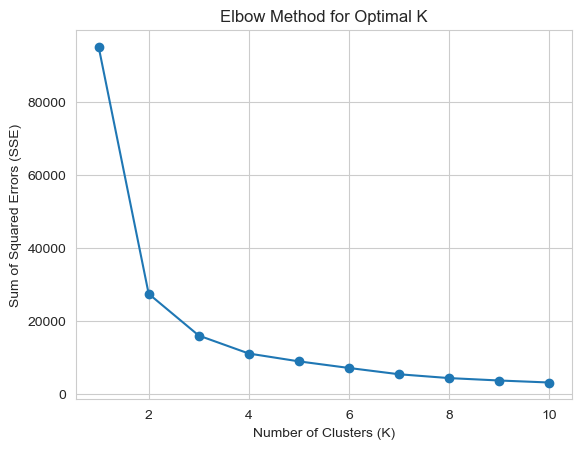

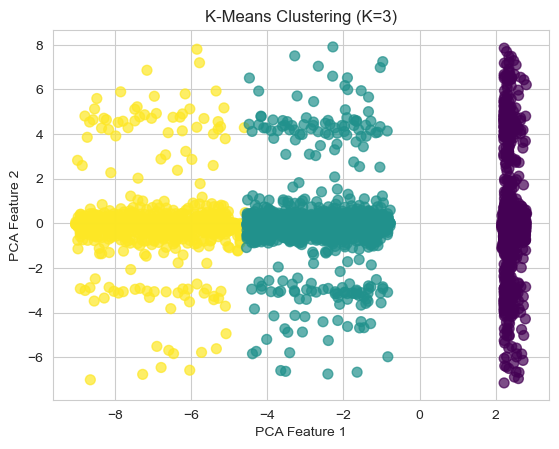


Cluster Characteristics (Mean of Original Features):
         Current_J0  Speed_J0  Current_J1  Speed_J1  Current_J2  Speed_J2  \
Cluster                                                                     
0         -0.054559  0.001896   -2.310450  0.000021   -1.206227  0.002342   
1         -0.053453  0.002113   -2.298305  0.000544   -1.211954  0.009110   
2         -0.022216  0.001355   -2.261169  0.000651   -1.158914 -0.003885   

         Current_J3  Speed_J3  Current_J4  Speed_J4  Current_J0_x_Speed_J0  \
Cluster                                                                      
0         -0.606223 -0.002762   -0.021229 -0.000648               0.005341   
1         -0.616577 -0.012098   -0.007498 -0.001587               0.005797   
2         -0.582168  0.002200   -0.051239 -0.000620               0.004784   

         Current_J1_x_Speed_J1  Current_J2_x_Speed_J2  Current_J3_x_Speed_J3  \
Cluster                                                                        
0        

In [117]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # For dimensionality reduction if needed
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X contains the scaled features from your previous steps
# Dimensionality reduction (Optional, but recommended for visualization with many features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Determine optimal number of clusters (e.g., using Elbow Method)
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca if X_pca is not None else X) # Fit on PCA-reduced data if used
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K')
plt.show()

# Based on the elbow plot, choose an optimal K, e.g., K=3
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_pca if X_pca is not None else X) # Fit on PCA-reduced data if used

# Visualize the clustering results
plt.scatter(X_pca[:, 0] if X_pca is not None else X.iloc[:, 0],
            X_pca[:, 1] if X_pca is not None else X.iloc[:, 1],
            c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('PCA Feature 1') # Or original feature name if PCA not used
plt.ylabel('PCA Feature 2') # Or original feature name if PCA not used
plt.title(f'K-Means Clustering (K={optimal_k})')
plt.show()

# Interpret the identified groups (clusters)
# Analyze the mean values of original features within each cluster
df_clustered = data.copy()
df_clustered['Cluster'] = clusters
print("\nCluster Characteristics (Mean of Original Features):")
print(df_clustered.groupby('Cluster')[X.columns].mean())


In [118]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X and y are already prepared features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt):.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1])
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Decision Tree')
plt.legend(loc="lower right")
plt.show()


ValueError: Unknown label type: continuous-multioutput. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.